# Overview
This is a implementation of Convolutional Neural Network (CNN) to classify weather images into 4 classes: Cloudy, Rain, Shine, Sunrise.

- Dataset: https://drive.google.com/file/d/1PowwArNBoGe9XmYwAhNUPraEiv0qAk2D/view?usp=drive_link

- Algorithm: CNN - Custom CNN and MobileNet V2
- Split: 80% train / 20% test (stratified)

## 1.0 Upload Data
To upload, download the dataset from the link above, then upload to the google colab folder. Then run the cells.

In [ ]:
import zipfile
import os

# File Path
zip_path = '/content/multiclassweatherdataset-updated.zip'
extract_path = '/content/weather_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


## 2.0 Data Preprocessing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

classes = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
img_size = 128

def prepare_dataset(data_dir, classes, img_size):
    images = []
    labels = []

    base_path = os.path.join(data_dir, 'Multi-class Weather Dataset')

    for i, label in enumerate(classes):
        path = os.path.join(base_path, label)
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                # Resize images
                img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
                images.append(np.array(img))
                labels.append(i)
            except:
                continue

    return np.array(images), np.array(labels)

# Load and Preprocess
X, y = prepare_dataset(extract_path, classes, img_size)

# Normalize pixel values to [0, 1]
X = X.astype('float32') / 255.0

print(f"Total images: {len(X)}")

Total images: 1225


## 3.0 Data Splitting

In [ ]:
# Split dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train)}")
print(f"Testing set: {len(X_test)}")

Training set: 980
Testing set: 245


## 4.0 Custom Convolutional Neural Network (CNN) Pipeline

### 4.1 Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Data Augmentation definition
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),  # Flips images left-to-right
    layers.RandomRotation(0.1),       # Rotates by 10%
    layers.RandomZoom(0.1),           # Zooms in/out 10%
])

### 4.2 Model Architecture
Building the CNN model based on our architecture, three convolutional blocks and regularization

In [ ]:
model = models.Sequential([
    # Add the augmentation layers first
    layers.InputLayer(input_shape=(128, 128, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Randomly shuts off 50% of neurons to prevent "memorization".
    layers.Dropout(0.5),

    # 4 dense layers as we have 4 classes
    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


### 4.3 Compiling the Model

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### 4.4 Early Stopping Callback

In [ ]:
# Will stop training if the validation loss does not improve for 5 epochs.
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### 4.5 Training the Model

In [ ]:
# Set epochs back to 50, but early_stop will stop it sooner (depends on the VL)
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.6204 - loss: 0.8976 - val_accuracy: 0.7878 - val_loss: 0.6519
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7510 - loss: 0.6109 - val_accuracy: 0.8082 - val_loss: 0.5678
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8051 - loss: 0.5102 - val_accuracy: 0.8286 - val_loss: 0.4712
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8224 - loss: 0.4703 - val_accuracy: 0.8327 - val_loss: 0.4959
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8449 - loss: 0.4442 - val_accuracy: 0.8694 - val_loss: 0.4529
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8459 - loss: 0.4258 - val_accuracy: 0.8571 - val_loss: 0.4541
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8551 - loss: 0.3687 - val_accuracy: 0.8531 - val_loss: 0.4532
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8571 - loss: 0.3635 - val_accuracy: 0.8694 - v

## 5.0 Model Evaluation

1.   Performance Metrics such as Accuracy, Precision, Recall, and F1-Score
2.   Confusion Matrix




### 5.1 Performance Metrics

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      Cloudy       0.80      0.82      0.81        65
        Rain       0.83      0.83      0.83        48
       Shine       0.89      0.88      0.88        56
     Sunrise       0.99      0.99      0.99        76

    accuracy                           0.89       245
   macro avg       0.88      0.88      0.88       245
weighted avg       0.89      0.89      0.89       245



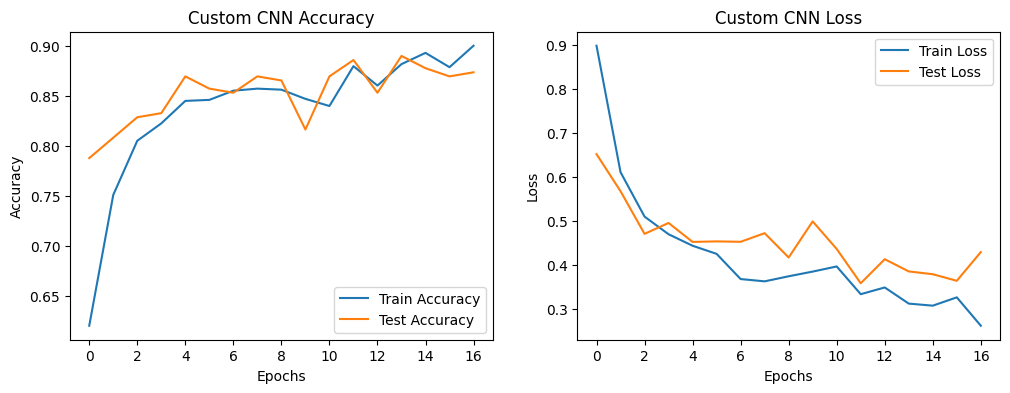

In [ ]:
# Performance Metrics (Accuracy, Precision, Recall, F1)
y_pred = np.argmax(model.predict(X_test), axis=-1)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=classes))

# Accuracy and Loss Graph
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Custom CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Custom CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 5.2 Confusion Matrix

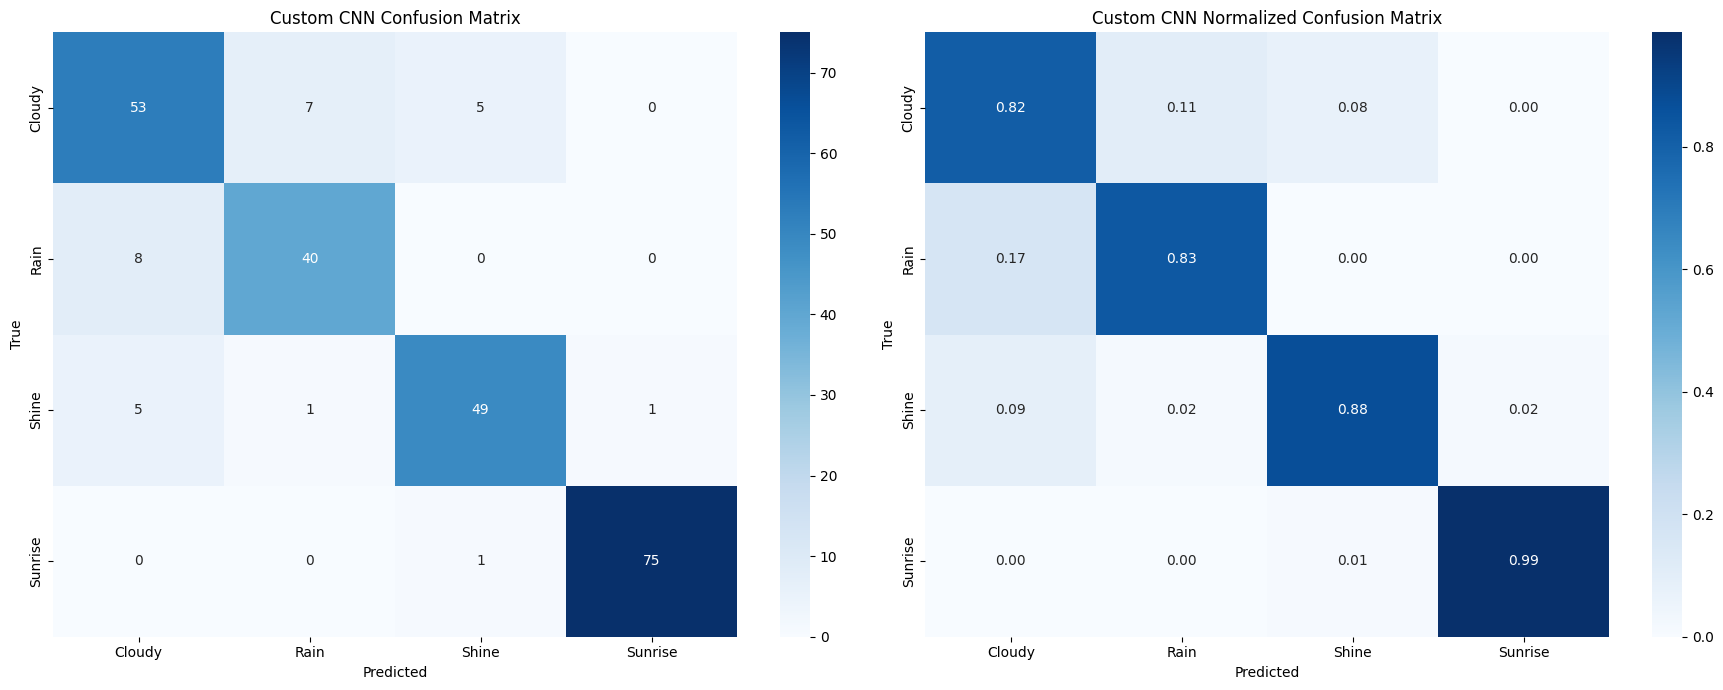

In [ ]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Raw Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Normalized version
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax[0])
ax[0].set_title('Custom CNN Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# Plot Normalized Confusion Matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set_title('Custom CNN Normalized Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## 6.0 Optimizing with Transfer Learning (MobileNetV2)

### 6.1 Import Libraries and Load Pre-Trained Base

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Load Pre-trained Base
# We use MobileNetV2 pre-trained on ImageNet
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Freeze weights to preserve learned features (only 7% trainable params out of all)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 6.2 Build the Classification Pipeline

In [ ]:
# 4 dense layers as we have 4 classes
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

transfer_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

### 6.3 Model Training

In [ ]:
history_transfer = transfer_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7561 - loss: 0.6219 - val_accuracy: 0.9265 - val_loss: 0.2321
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9061 - loss: 0.2535 - val_accuracy: 0.9429 - val_loss: 0.1621
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9469 - loss: 0.1580 - val_accuracy: 0.9510 - val_loss: 0.1474
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9673 - loss: 0.1067 - val_accuracy: 0.9388 - val_loss: 0.1346
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9663 - loss: 0.0961 - val_accuracy: 0.9347 - val_loss: 0.1573
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9735 - loss: 0.0777 - val_accuracy: 0.9469 - val_loss: 0.1272
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9827 - loss: 0.0560 - val_accuracy: 0.9388 - val_loss: 0.1405
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9847 - loss: 0.0509 - val_accuracy: 0.9551 - va

### 6.4 Model Evaluation

1.   Performance Metrics such as Accuracy, Precision, Recall, and F1-Score
2.   Confusion Matrix




6.4.1 Performance Metrics

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

--- MobileNetV2 Classification Report ---
              precision    recall  f1-score   support

      Cloudy       0.91      0.95      0.93        65
        Rain       1.00      1.00      1.00        48
       Shine       0.96      0.88      0.92        56
     Sunrise       0.95      0.97      0.96        76

    accuracy                           0.95       245
   macro avg       0.96      0.95      0.95       245
weighted avg       0.95      0.95      0.95       245



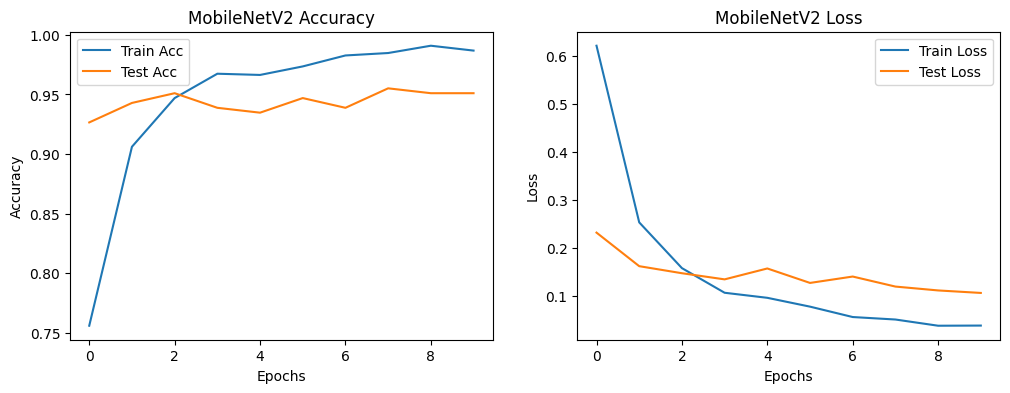

In [ ]:
# Generate Predictions
y_pred_transfer = np.argmax(transfer_model.predict(X_test), axis=-1)

# Classification Report
print("\n--- MobileNetV2 Classification Report ---")
print(classification_report(y_test, y_pred_transfer, target_names=classes))

# Training History Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Train Acc')
plt.plot(history_transfer.history['val_accuracy'], label='Test Acc')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Test Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

6.4.2 Confusion Matrix

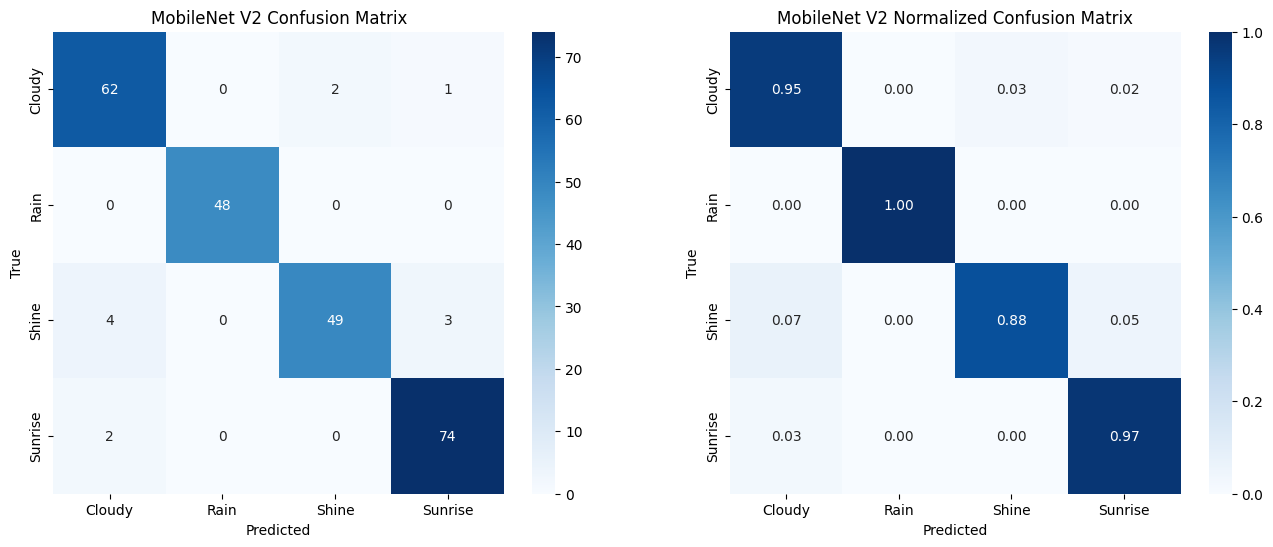

In [ ]:
# Raw Confusion Matrix
cm = confusion_matrix(y_test, y_pred_transfer)

# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Raw Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax[0])
ax[0].set_title('MobileNet V2 Confusion Matrix')
ax[0].set_ylabel('True')
ax[0].set_xlabel('Predicted')

# Percentages
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set_title('MobileNet V2 Normalized Confusion Matrix')
ax[1].set_ylabel('True')
ax[1].set_xlabel('Predicted')

plt.show()